# Back test stock data with model

---

Test predictions from Heston process from an earlier date on a given underlying.

In [1]:
import sys
sys.path.append('../')

from datetime import date
import numpy as np
import matplotlib.pyplot as plt

from stockhealth.analyzer import TimeSeries as Ts
from stockhealth.training import Trends
from stockhealth.simulation import MonteCarlosWithHeston as McsHeston
from stockhealth.model import _NUMBER_OF_TRADING_DAYS_PER_YEAR as _NTD

from stockhealth.utilities.graph import plot as ProbPlt

In [2]:
stock = Ts(ticker='SPY')
mdl = Trends(stock=stock)
sim_stock = McsHeston(
    trained_model=mdl,
    number_of_days=30,
    start_date=date(2020, 7, 1)
)
sim_stock.solve()

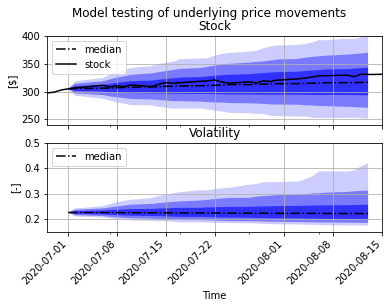

In [3]:
fig = plt.figure('Model validation of underlying')
axs = fig.subplots(nrows=2, ncols=1, sharex=True)

ProbPlt(sim_stock.S, fig, axs[0])
stock.history__.Close.plot(ax=axs[0], grid=True, style='-', color='k', label='stock')
axs[0].set_ylim([240, 400])
_ = axs[0].legend(loc='upper left')

ProbPlt(sim_stock.V, fig, axs[1])
axs[1].set_xlim([date(2020, 6, 28), date(2020, 8, 15)])
axs[1].set_ylim([0.15, 0.5])
_ = axs[1].legend(loc='upper left')

fig.suptitle('Model testing of underlying price movements')
axs[0].set_title('Stock')
axs[1].set_title('Volatility')

axs[0].set_ylabel('[$]')
_ = axs[1].set_ylabel('[-]')
